/Users/lorenzo.consoli/micromamba/envs/sc-flow-tools/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 10/10 [00:00<00:00, 18.32it/s]


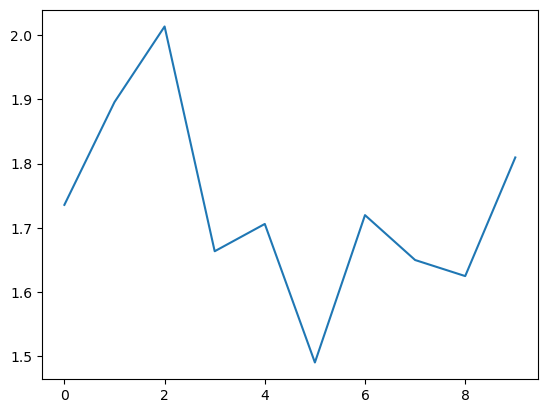

In [1]:
# import libraries
import matplotlib.pyplot as plt
from sc_flow import SCFlow
from sc_flow.dataset.toy_data import get_toy_dataset

# create dataset
adata = get_toy_dataset("moons", noise=0.1).adata

# register data and initialize model
SCFlow.register_adata(adata)
model = SCFlow(
    method_id="cfm",
    vf_decoder_mlp_kwargs={
        "hidden_dims": [
            32,
            32,
        ]
    },
    lr=1e-4,
    device_id="mps",
    time_features_id="torch-cfm",
    conditioning_id="resnet1d",
    # probability_path=probability_paths.SchrodingerBridgeProbabilityPath(1.0)
)

# train model
model.train(
    adata,
    n_train_steps=10,
)

plt.plot(model.trainer._training_logs["loss"])

Predicting: 100%|██████████| 1/1 [00:00<00:00,  3.82it/s]


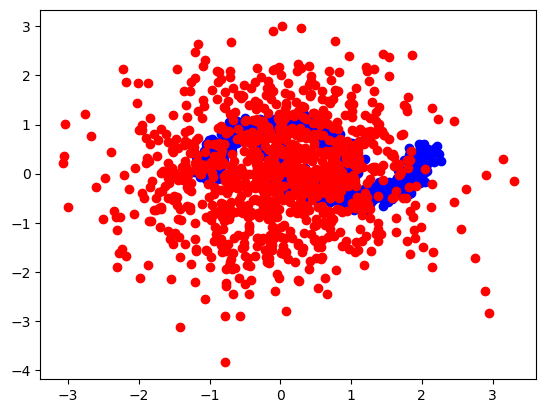

In [3]:
# predict
adata_pred = model.predict(adata)

# visualize
plt.scatter(
    adata.X[:, 0],
    adata.X[:, 1],
    color="blue",
)
plt.scatter(adata_pred.X[:, 0], adata_pred.X[:, 1], color="red")